# Plot1 - CarbonSavings vs. MakeSpan

In [39]:
import pandas as pd
import glob
import os

root_dir = f"../Logs/GeneralExp"

# Define the pattern
pattern = "10J_5S_3O_MeanOp=7_v*.csv"

# Get list of matching files
csv_files = glob.glob(f"{root_dir}/{pattern}")

# Read and concatenate all files
df_union = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)

print(f"✅ Loaded and merged {len(csv_files)} files. Final shape: {df_union.shape}")

✅ Loaded and merged 8 files. Final shape: (3748, 22)


In [40]:
df_logs = df_union[["Instance", "IsCarbonAware", "Horizon", "MaxMakeSpan", "MinMakeSpan", "SlackCoeff", "Makespan", "CarbonConsumption(g)"]]

In [41]:
df_logs.head(12)

,Instance,IsCarbonAware,Horizon,MaxMakeSpan,MinMakeSpan,SlackCoeff,Makespan,CarbonConsumption(g)
0,0,False,192,192,31,1.0,31,12934.00
1,0,True,192,31,31,1.0,31,12930.00
2,0,True,192,47,31,1.5,32,12930.00
3,0,True,192,62,31,2.0,62,12862.00
4,1,False,192,192,48,1.0,48,20650.00
5,1,True,192,48,48,1.0,48,20626.00
6,1,True,192,72,48,1.5,72,19216.00
7,1,True,192,96,48,2.0,96,14205.50
8,2,False,192,192,49,1.0,49,21568.75
9,2,True,192,49,49,1.0,49,21568.50


In [48]:
baseline = df_logs[df_logs["IsCarbonAware"] == False][["Makespan"]]

In [49]:
import numpy as np
np.average(baseline["Makespan"])
# np.std(baseline["Makespan"])

np.float64(43.47491995731057)

In [20]:
baseline.head(2)

,Makespan
0,31
4,48


In [42]:

# First, get baseline carbon consumption per instance where IsCarbonAware is False
baseline = df_logs[df_logs["IsCarbonAware"] == False][["Instance", "CarbonConsumption(g)"]]
baseline = baseline.rename(columns={"CarbonConsumption(g)": "BaselineCarbon"})
# Merge it back to original df to align baseline carbon for each instance
df_logs = df_logs.merge(baseline, on="Instance", how="left")
# Calculate savings
df_logs["CarbonSavings(%)"] = ((df_logs["BaselineCarbon"] - df_logs["CarbonConsumption(g)"]) / df_logs["BaselineCarbon"]) * 100
df_logs.drop(columns=["BaselineCarbon"], inplace=True)
# Optional: round to 2 decimal places
df_logs["CarbonSavings(%)"] = df_logs["CarbonSavings(%)"].round(2)


In [43]:
df_logs.head(12)

,Instance,IsCarbonAware,Horizon,MaxMakeSpan,MinMakeSpan,SlackCoeff,Makespan,CarbonConsumption(g),CarbonSavings(%)
0,0,False,192,192,31,1.0,31,12934.00,0.00
1,0,True,192,31,31,1.0,31,12930.00,0.03
2,0,True,192,47,31,1.5,32,12930.00,0.03
3,0,True,192,62,31,2.0,62,12862.00,0.56
4,1,False,192,192,48,1.0,48,20650.00,0.00
5,1,True,192,48,48,1.0,48,20626.00,0.12
6,1,True,192,72,48,1.5,72,19216.00,6.94
7,1,True,192,96,48,2.0,96,14205.50,31.21
8,2,False,192,192,49,1.0,49,21568.75,0.00
9,2,True,192,49,49,1.0,49,21568.50,0.00


In [44]:
import pandas as pd

# Filter only carbon-aware rows
df_filtered = df_logs[df_logs["IsCarbonAware"] == True].copy()
df_plot = df_filtered.groupby("SlackCoeff")["CarbonSavings(%)"].mean().reset_index()

In [45]:
import pandas as pd

# Filter for carbon-aware runs only
df_box = df_logs[df_logs["IsCarbonAware"] == True].copy()
df_box["MakeSpanRatio"] = df_box["SlackCoeff"]
df_box["MakeSpanRatio"] = df_box["MakeSpanRatio"].astype(str)

In [70]:
df_box.head(8)

,Instance,IsCarbonAware,Horizon,MaxMakeSpan,MinMakeSpan,Makespan,CarbonConsumption(g),CarbonSavings(%),MakeSpanRatio
1,0,True,288,14,14,14,745.00,0.00,1.0
2,0,True,288,28,14,23,745.00,0.00,2.0
3,0,True,288,70,14,20,745.00,0.00,5.0
4,0,True,288,140,14,17,745.00,0.00,10.0
5,0,True,288,288,14,264,355.83,52.24,Whole Day
7,1,True,288,21,21,21,1187.00,0.23,1.0
8,1,True,288,42,21,24,1187.00,0.23,2.0
9,1,True,288,105,21,24,1187.00,0.23,5.0


In [25]:
df_plot

,SlackCoeff,CarbonSavings(%)
0,1.0,0.874725
1,1.5,11.158498
2,2.0,29.269853


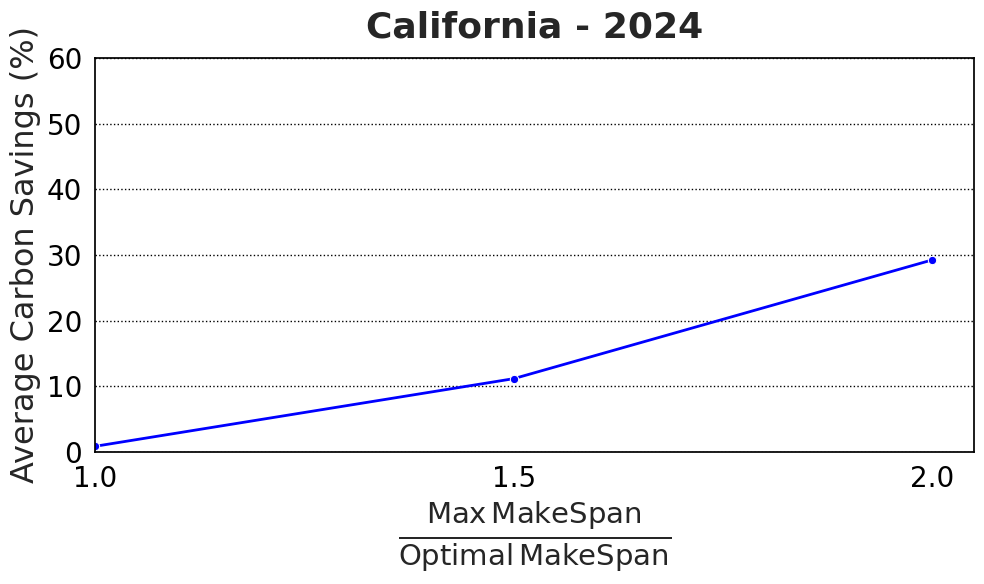

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

location = "California"

# Seaborn & matplotlib styling
sns.set(style="whitegrid", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})

# Ensure 'x_label' is treated as string (categorical)
df_plot["SlackCoeff"] = df_plot["SlackCoeff"].astype(str)

plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=df_plot,
    x="SlackCoeff",
    y="CarbonSavings(%)",
    marker="o",
    linewidth=2,
    color="blue"
)

# Labels
ax.set_xlabel(r"$\frac{\mathrm{Max\,MakeSpan}}{\mathrm{Optimal\,MakeSpan}}$", fontsize=30)
ax.set_ylabel("Average Carbon Savings (%)", fontsize=23)

# Axis limits and tick font sizes
ax.set_ylim(0, 60)
ax.set_xlim(0)
ax.tick_params(axis='x', labelsize=20, color='black')
ax.tick_params(axis='y', labelsize=20, color='black')

# Add minor ticks on y-axis every 2 units
ax.yaxis.set_minor_locator(MultipleLocator(2))
ax.tick_params(axis='y', which='minor', direction='in', length=4, color='gray')

# Grid settings
ax.grid(axis='x', visible=False)  # No x-grid
ax.grid(axis='y', which='major', color='black', linestyle=':', linewidth=1)

# Black border and ticks
ax.tick_params(axis='both', color='black', labelcolor='black')
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    
ax.set_title(f"{location} - 2024", fontsize=26, fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig(f"./GeneralExp/LinePlot-{location}.png", dpi=300, bbox_inches='tight')
plt.show()

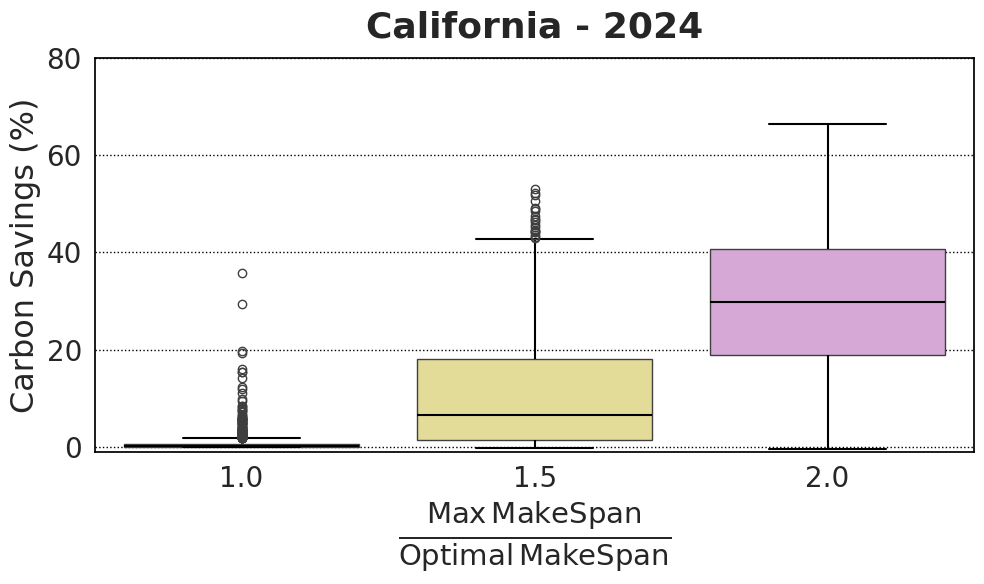

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

location = "California"
# Setup
sns.set(style="whitegrid", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})

# Dynamically match colors to number of unique categories
unique_labels = sorted(df_box["SlackCoeff"].unique())
inner_colors = ["lightseagreen", "khaki", "plum", "lightsalmon", "skyblue", "wheat", "orchid"]
palette = inner_colors[:len(unique_labels)]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
box = sns.boxplot(
    data=df_box,
    x="SlackCoeff",
    y="CarbonSavings(%)",
    hue="SlackCoeff",
    palette=palette,
    dodge=False,
    legend=False
)

# Axis labels
ax.set_xlabel(r"$\frac{\mathrm{Max\,MakeSpan}}{\mathrm{Optimal\,MakeSpan}}$", fontsize=30)
ax.set_ylabel("Carbon Savings (%)", fontsize=23)

# Axis ticks and limits
ax.set_ylim(-1, 80)
ax.tick_params(axis='x', labelsize=20, color='black')
ax.tick_params(axis='y', labelsize=20, color='black')

# Minor ticks
ax.yaxis.set_minor_locator(MultipleLocator(2))
ax.tick_params(axis='y', which='minor', direction='in', length=4, color='gray')

# Grid & borders
ax.grid(axis='x', visible=False)
ax.grid(axis='y', which='major', color='black', linestyle=':', linewidth=1)
for spine in ax.spines.values():
    spine.set_edgecolor('black')

# Box edges and medians
for i, patch in enumerate(ax.artists):
    patch.set_edgecolor("black")
    patch.set_linewidth(1.5)
    patch.set_facecolor(palette[i % len(palette)])
for line in ax.lines:
    line.set_color("black")
    line.set_linewidth(1.5)
ax.set_title(f"{location} - 2024", fontsize=26, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(f"./GeneralExp/BoxPlot-{location}.png", dpi=300, bbox_inches='tight')
plt.show()